In [39]:

import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random


### 1. Linear Congruential Generator

The **Linear Congruential Generator (LCG)** produces pseudo-random numbers using the recurrence relation:

$$X_{i+1} = (a \cdot X_i + b) \mod M$$

- Returns $n$ uniform pseudo-random numbers in $[0, 1)$
- Uses only **integer arithmetic** internally

In [40]:

def lcg(n, a, b, M, seed=3):
    numbers = []
    x = seed % M  # ensure seed is valid integer
    for _ in range(n):
        x = (a * x + b) % M   # pure integer arithmetic
        numbers.append(x / M)  # scale to [0, 1)
    return numbers

### 1(a) — Generate 10,000 pseudo-random numbers and plot a histogram

We use a simple starting choice of parameters and plot the distribution across 10 bins.
Expected count per bin = $n / k = 10000 / 10 = 1000$ if the generator is uniform.

In [41]:
N = 10_000
K = 10        #number of bins
a, b, M = 5, 1, 64   #starting parameters

data_1 = lcg(N, a, b, M, seed=3)
print(data_1[:10])  

[0.25, 0.265625, 0.34375, 0.734375, 0.6875, 0.453125, 0.28125, 0.421875, 0.125, 0.640625]


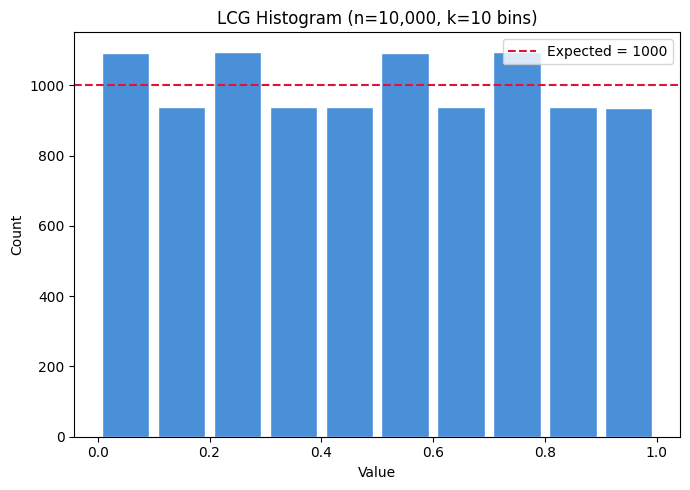

Counts per bin: [1092, 939, 1096, 937, 938, 1093, 938, 1094, 937, 936]
Min: 936,  Max: 1096,  Expected: 1000


In [42]:
#histogram from scratch
counts = [0] * K
for x in data_1:
    idx = int(x * K)
    if idx == K:       #edge case x == 1.0
        idx = K - 1
    counts[idx] += 1

bin_edges   = [i / K for i in range(K + 1)]
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(K)]
expected    = N / K

#plot
plt.figure(figsize=(7, 5))
plt.bar(bin_centers, counts, width=0.085, color="#4a90d9", edgecolor="white")
plt.axhline(expected, color="crimson", linestyle="--", linewidth=1.5, label=f"Expected = {expected:.0f}")
plt.title("LCG Histogram (n=10,000, k=10 bins)")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Counts per bin: {counts}")
print(f"Min: {min(counts)},  Max: {max(counts)},  Expected: {expected:.0f}")

In [49]:
print(f"\nUnique values: {len(set(data_1))} out of {N}")


Unique values: 64 out of 10000


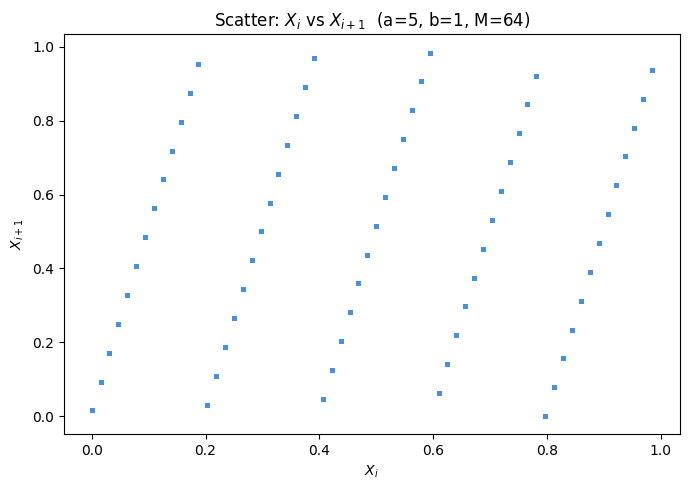

Unique values: 64 out of 10000


In [43]:
# Scatter plot: X_i vs X_{i+1}
plt.figure(figsize=(7, 5))
plt.scatter(data_1[:-1], data_1[1:], s=5, alpha=0.5, color="#4a90d9")
plt.title("Scatter: $X_i$ vs $X_{i+1}$  (a=5, b=1, M=64)")
plt.xlabel("$X_i$")
plt.ylabel("$X_{i+1}$")
plt.tight_layout()
plt.show()

# Also print number of unique values
print(f"Unique values: {len(set(data_1))} out of {N}")

### 1(b) — Chi-square test

Test whether the counts per bin are consistent with a uniform distribution.

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}, \quad E_i = n/k$$

Reject $H_0$ (uniformity) if $\chi^2 > \chi^2_{k-1,\ 0.05}$. For $k=10$ bins, the critical value is **16.919**.

In [21]:
def chi_square_test(data, k=10):
    n = len(data)
    counts = [0] * k
    for x in data:
        idx = min(int(x * k), k - 1)
        counts[idx] += 1
    
    expected = n / k
    chi2 = sum((o - expected)**2 / expected for o in counts)
    df = k - 1
    critical = 16.919   # chi2 table: df=9, alpha=0.05
    
    print(f"χ² statistic : {chi2:.4f}")
    print(f"Critical value (df=9, α=0.05): {critical}")
    print(f"→ {'FAIL (not uniform)' if chi2 > critical else 'PASS (looks uniform)'}")
    return chi2

chi2_bad = chi_square_test(data_1)

χ² statistic : 58.6080
Critical value (df=9, α=0.05): 16.919
→ FAIL (not uniform)


### 1(b) — Kolmogorov-Smirnov (KS) Test

Measures the maximum distance between the empirical CDF $F_n(x)$ and the theoretical uniform CDF $F(x) = x$:

$$D_n = \max_{i} \left| F_n(x_i) - x_i \right|$$

Reject $H_0$ if $D_n > \frac{1.36}{\sqrt{n}}$ at $\alpha = 0.05$.

In [23]:
def ks_test(data):
    n = len(data)
    sorted_data = sorted(data)
    
    d_plus  = max((i + 1) / n - x for i, x in enumerate(sorted_data))
    d_minus = max(x - i / n       for i, x in enumerate(sorted_data))
    D = max(d_plus, d_minus)
    
    critical = 1.36 / n**0.5   # approx critical value at alpha=0.05
    
    print(f"D statistic    : {D:.6f}")
    print(f"Critical value (α=0.05): {critical:.6f}")
    print(f"→ {'FAIL (not uniform)' if D > critical else 'PASS (looks uniform)'}")
    return D

D_bad = ks_test(data_1)

D statistic    : 0.015875
Critical value (α=0.05): 0.013600
→ FAIL (not uniform)


### 1(b) — Runs Test

Tests for independence (are consecutive values correlated?)

A run is a consecutive sequence of values all above or all below 0.5.
Under $H_0$ (independence), the number of runs $R$ is approximately normal:

$$Z = \frac{R - \mu_R}{\sigma_R}, \quad \mu_R = \frac{2n_1 n_2}{n} + 1, \quad \sigma_R^2 = \frac{2n_1 n_2 (2n_1 n_2 - n)}{n^2(n-1)}$$

Reject $H_0$ if $|Z| > 1.96$ at $\alpha = 0.05$.

In [25]:
def runs_test(data):
    n = len(data)
    signs = [1 if x >= 0.5 else 0 for x in data]

    # count runs
    runs = 1
    for i in range(1, n):
        if signs[i] != signs[i-1]:
            runs += 1

    n1 = sum(signs)       # count above 0.5
    n2 = n - n1           # count below 0.5

    mu    = (2 * n1 * n2) / n + 1
    sigma2 = (2 * n1 * n2 * (2 * n1 * n2 - n)) / (n**2 * (n - 1))
    Z = (runs - mu) / sigma2**0.5

    print(f"Runs observed  : {runs}")
    print(f"Expected runs  : {mu:.1f}")
    print(f"Z statistic    : {Z:.4f}")
    print(f"→ {'FAIL (not independent)' if abs(Z) > 1.96 else 'PASS (looks independent)'}")
    return Z

Z_bad = runs_test(data_1)

Runs observed  : 4064
Expected runs  : 5001.0
Z statistic    : -18.7409
→ FAIL (not independent)


### 1(b) — correlation tests for some h-values

In [34]:
def correlation_test(data, h=1):
    n = len(data) - h
    x = data[:n]
    y = data[h:h+n]

    mean_x = sum(x) / n
    mean_y = sum(y) / n

    numerator = sum((x[i] - mean_x) * (y[i] - mean_y) for i in range(n))
    denominator_x = sum((x[i] - mean_x)**2 for i in range(n))
    denominator_y = sum((y[i] - mean_y)**2 for i in range(n))

    r = numerator / (denominator_x * denominator_y)**0.5

    print(f"h = {h}, correlation r = {r:.6f}")
    return r

for h in [1, 2, 5, 10]:
    correlation_test(data_1, h)

h = 1, correlation r = 0.180674
h = 2, correlation r = 0.091419
h = 5, correlation r = 0.075206
h = 10, correlation r = -0.142615


### Summary — Bad Generator (a=5, b=1, M=64)

| Test | Statistic | Critical Value | Result |
|------|-----------|---------------|--------|
| Chi-square | $\chi^2 = 58.61$ | $16.919$ | FAIL ✗ |
| KS test | $D = 0.0159$ | $0.0136$ | FAIL ✗ |
| Runs test | $Z = -18.74$ | $\|Z\| < 1.96$ | FAIL ✗ |

**Conclusion:** This generator is clearly inadequate:
- Only **64 unique values** (M=64 is far too small)
- Chi-square fails badly — counts per bin are uneven
- KS fails — empirical CDF deviates from uniform
- Runs test fails with $|Z| = 18.74$ — massive non-independence, 
consecutive values are strongly correlated

### 1(c) — Experimenting with Parameters

We experiment with different values of $a$, $b$, and $M$ to find a decent generator.
The key rules for a good LCG (**Hull-Dobell theorem**) for full period are:
1. $b$ and $M$ are coprime
2. $a - 1$ is divisible by all prime factors of $M$
3. If $M$ is divisible by 4, then $a - 1$ must also be divisible by 4

χ² statistic : 58.6080
Critical value (df=9, α=0.05): 16.919
→ FAIL (not uniform)
D statistic    : 0.015875
Critical value (α=0.05): 0.013600
→ FAIL (not uniform)
Runs observed  : 4064
Expected runs  : 5001.0
Z statistic    : -18.7409
→ FAIL (not independent)
χ² statistic : 0.2060
Critical value (df=9, α=0.05): 16.919
→ PASS (looks uniform)
D statistic    : 0.001353
Critical value (α=0.05): 0.013600
→ PASS (looks uniform)
Runs observed  : 4007
Expected runs  : 5001.0
Z statistic    : -19.8809
→ FAIL (not independent)
χ² statistic : 9.7800
Critical value (df=9, α=0.05): 16.919
→ PASS (looks uniform)
D statistic    : 0.007888
Critical value (α=0.05): 0.013600
→ PASS (looks uniform)
Runs observed  : 4846
Expected runs  : 5001.0
Z statistic    : -3.1001
→ FAIL (not independent)
χ² statistic : 18.3460
Critical value (df=9, α=0.05): 16.919
→ FAIL (not uniform)
D statistic    : 0.008715
Critical value (α=0.05): 0.013600
→ PASS (looks uniform)
Runs observed  : 5035
Expected runs  : 5001.0
Z st

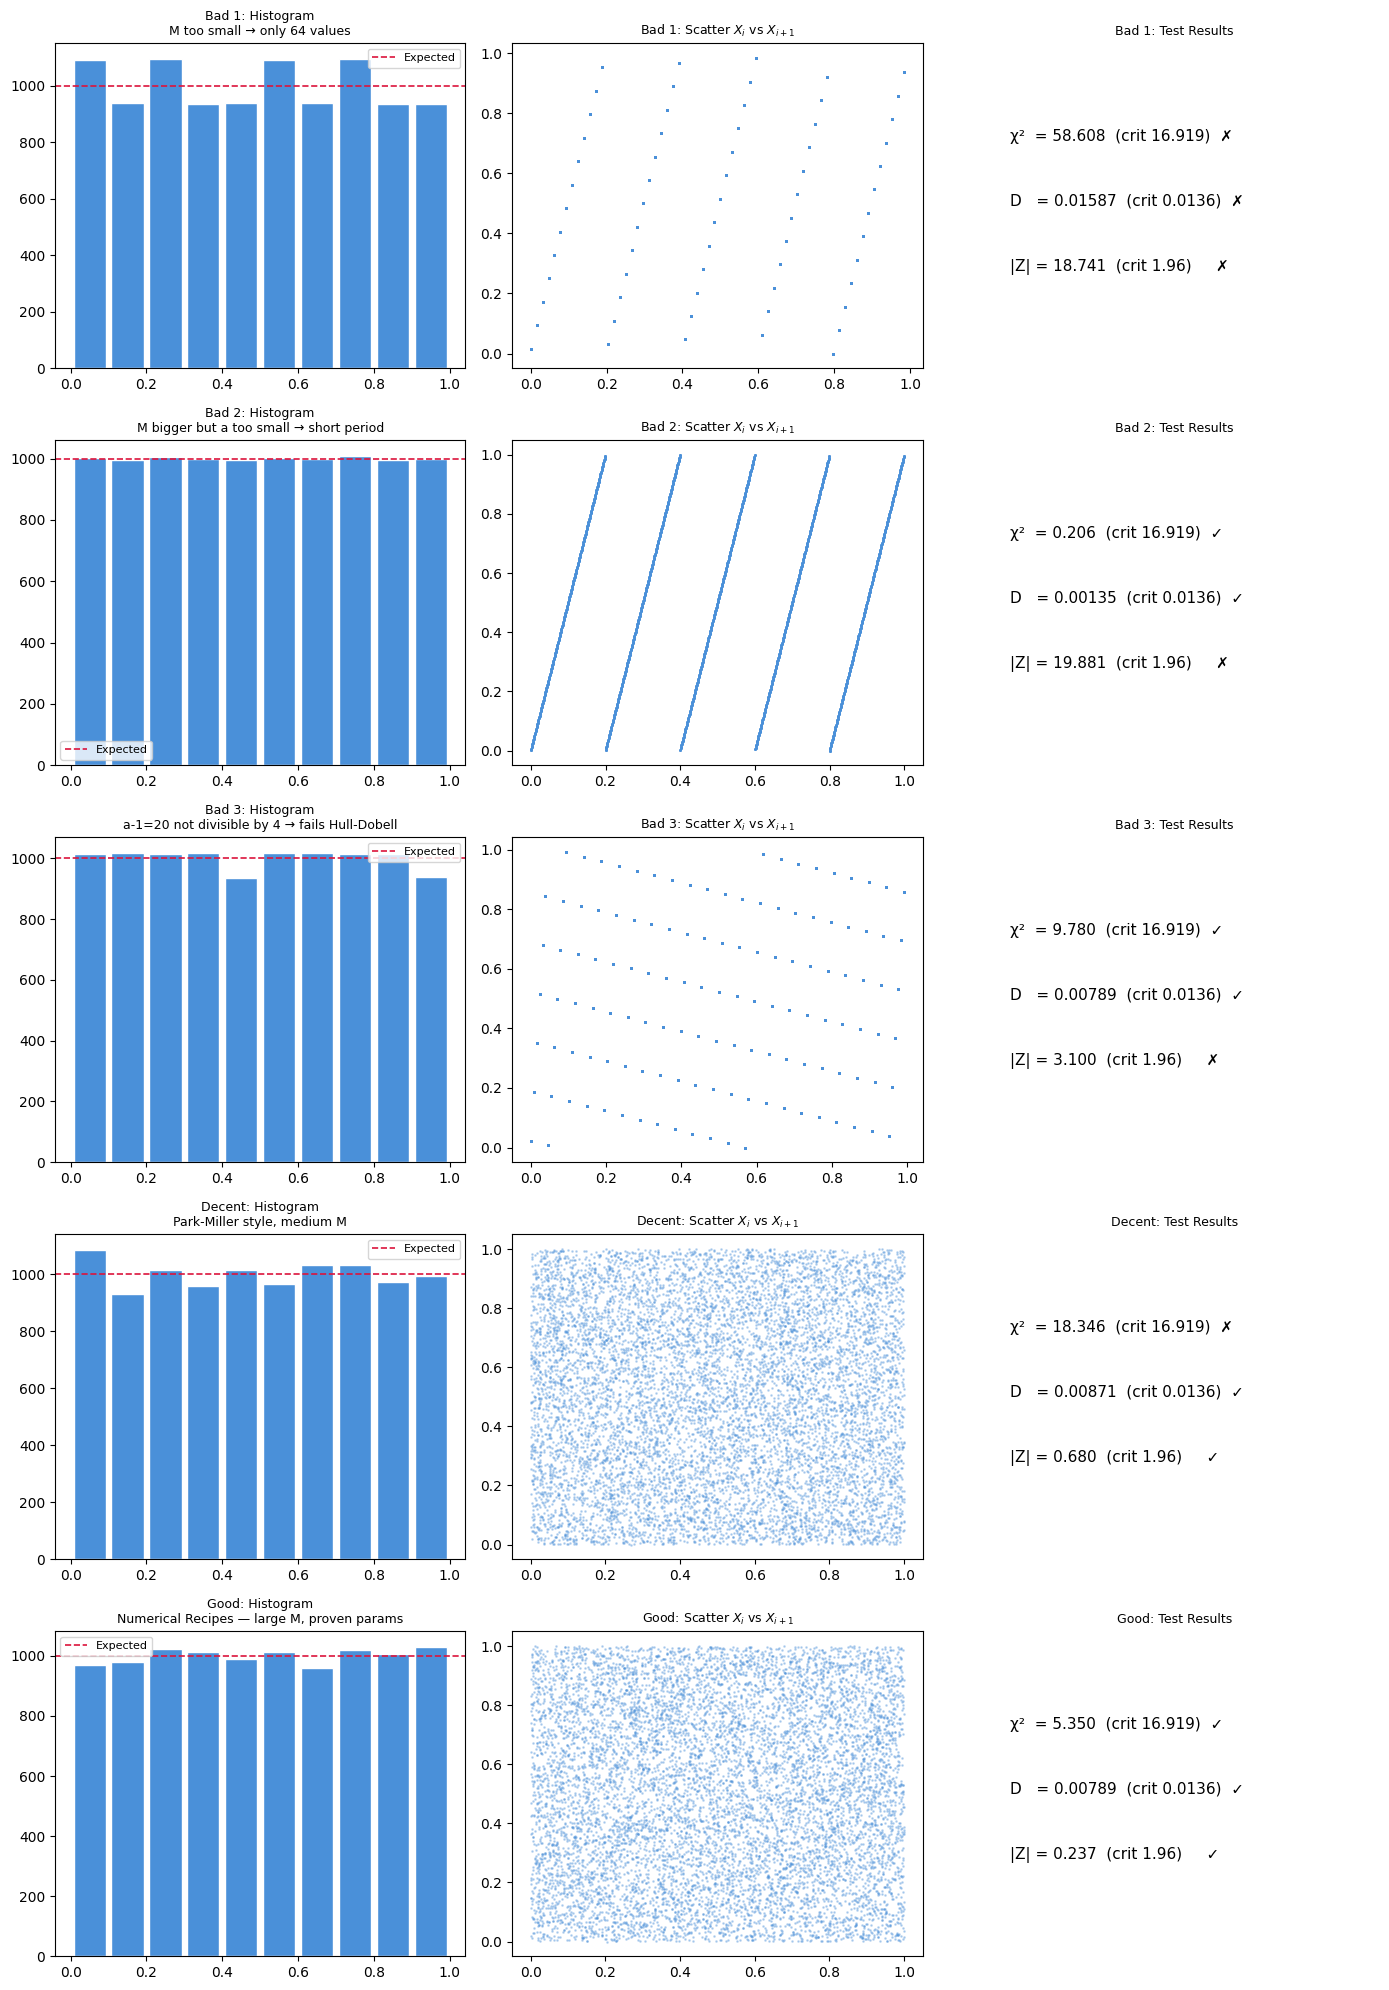

In [44]:
configs = [
    # (a,    b,   M,        label,         why)
    (5,      1,   64,       "Bad 1",       "M too small → only 64 values"),
    (5,      1,   1024,     "Bad 2",       "M bigger but a too small → short period"),
    (21,     3,   128,      "Bad 3",       "a-1=20 not divisible by 4 → fails Hull-Dobell"),
    (1366,   150477, 714025, "Decent",     "Park-Miller style, medium M"),
    (1664525, 1013904223, 2**31, "Good",   "Numerical Recipes — large M, proven params"),
]

fig, axes = plt.subplots(len(configs), 3, figsize=(14, 4 * len(configs)))

for row, (a, b, M, label, why) in enumerate(configs):
    data = lcg(N, a, b, M, seed=3)

    # histogram
    counts = [0] * K
    for x in data:
        counts[min(int(x * K), K-1)] += 1
    bin_centers = [(i + 0.5) / K for i in range(K)]

    axes[row, 0].bar(bin_centers, counts, width=0.085, color="#4a90d9", edgecolor="white")
    axes[row, 0].axhline(N/K, color="crimson", linestyle="--", linewidth=1.2, label="Expected")
    axes[row, 0].set_title(f"{label}: Histogram\n{why}", fontsize=9)
    axes[row, 0].legend(fontsize=8)

    # scatter
    axes[row, 1].scatter(data[:-1], data[1:], s=1, alpha=0.3, color="#4a90d9")
    axes[row, 1].set_title(f"{label}: Scatter $X_i$ vs $X_{{i+1}}$", fontsize=9)

    # run tests
    chi2, _ = chi_square_test(data, K), None
    D       = ks_test(data)
    Z       = runs_test(data)

    axes[row, 2].axis("off")
    axes[row, 2].text(0.1, 0.7, f"χ²  = {chi2:.3f}  (crit 16.919)  {'✓' if chi2 < 16.919 else '✗'}",
                      fontsize=11, transform=axes[row, 2].transAxes)
    axes[row, 2].text(0.1, 0.5, f"D   = {D:.5f}  (crit 0.0136)  {'✓' if D < 0.0136 else '✗'}",
                      fontsize=11, transform=axes[row, 2].transAxes)
    axes[row, 2].text(0.1, 0.3, f"|Z| = {abs(Z):.3f}  (crit 1.96)     {'✓' if abs(Z) < 1.96 else '✗'}",
                      fontsize=11, transform=axes[row, 2].transAxes)
    axes[row, 2].set_title(f"{label}: Test Results", fontsize=9)

plt.tight_layout()
plt.show()

### Generate plots to the report

In [46]:
N = 10_000
K = 10       
a, b, M = 1664525, 1013904223, 2**31 

data_2 = lcg(N, a, b, M, seed=3)
print(data_2[:10]) 

[0.4744612602517009, 0.10135640809312463, 0.7473171539604664, 0.5578319909982383, 0.7669522883370519, 0.7298801769502461, 0.2736740540713072, 0.776988988276571, 0.06784700509160757, 0.5082860537804663]


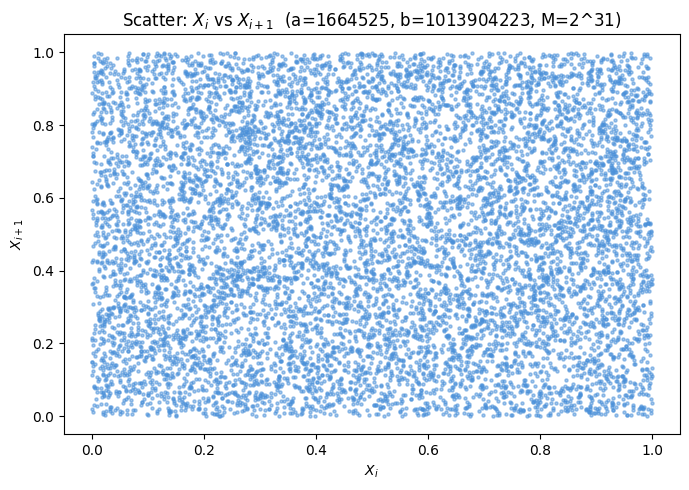

Unique values: 10000 out of 10000


In [47]:
# Scatter plot: X_i vs X_{i+1}
plt.figure(figsize=(7, 5))
plt.scatter(data_2[:-1], data_2[1:], s=5, alpha=0.5, color="#4a90d9")
plt.title("Scatter: $X_i$ vs $X_{i+1}$  (a=1664525, b=1013904223, M=2^31)")
plt.xlabel("$X_i$")
plt.ylabel("$X_{i+1}$")
plt.tight_layout()
plt.show()

# Also print number of unique values
print(f"Unique values: {len(set(data_2))} out of {N}")

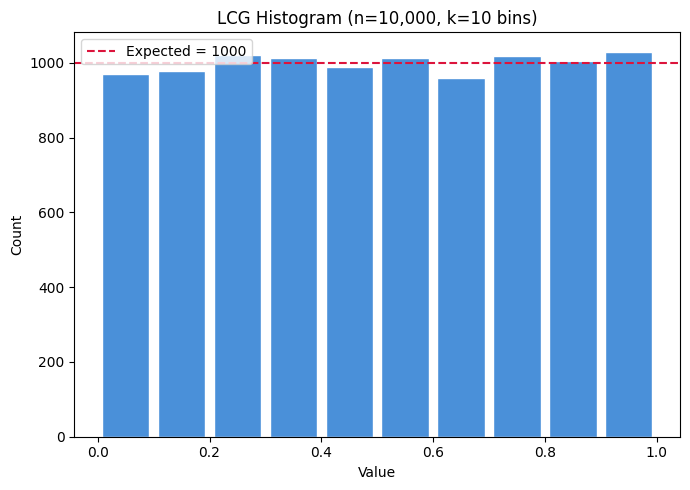

Counts per bin: [969, 979, 1022, 1013, 989, 1014, 959, 1019, 1006, 1030]
Min: 959,  Max: 1030,  Expected: 1000


In [ ]:
#histogram from scratch
counts = [0] * K
for x in data_2:
    idx = int(x * K)
    if idx == K:       
        idx = K - 1
    counts[idx] += 1

bin_edges   = [i / K for i in range(K + 1)]
bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(K)]
expected    = N / K

plt.figure(figsize=(7, 5))
plt.bar(bin_centers, counts, width=0.085, color="#4a90d9", edgecolor="white")
plt.axhline(expected, color="crimson", linestyle="--", linewidth=1.5, label=f"Expected = {expected:.0f}")
plt.title("LCG Histogram (n=10,000, k=10 bins)")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Counts per bin: {counts}")
print(f"Min: {min(counts)},  Max: {max(counts)},  Expected: {expected:.0f}")

## Exercise 2 — System Generator

I will now apply Python's built-in `random.random()` which uses the **Mersenne Twister (MT19937)** algorithm.
It has a period of $2^{19937} - 1$ — astronomically larger than any LCG.
I will run the exact same statistical tests as in Part 1(b) for comparison.

  System Generator: Python random.random()
  Algorithm: Mersenne Twister (MT19937)
  Period: 2^19937 - 1


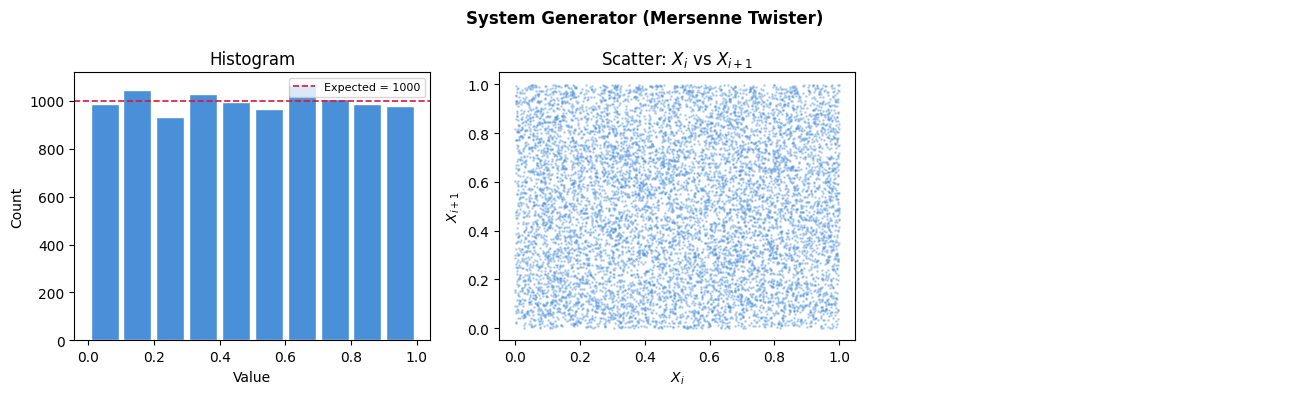


--- Statistical Tests ---
χ² statistic : 13.6560
Critical value (df=9, α=0.05): 16.919
→ PASS (looks uniform)

D statistic    : 0.006260
Critical value (α=0.05): 0.013600
→ PASS (looks uniform)

Runs observed  : 5060
Expected runs  : 5001.0
Z statistic    : 1.1805
→ PASS (looks independent)

Unique values: 10000 out of 10000


In [45]:

random.seed(42)
data_sys = [random.random() for _ in range(N)]

print("=" * 45)
print("  System Generator: Python random.random()")
print("  Algorithm: Mersenne Twister (MT19937)")
print("  Period: 2^19937 - 1")
print("=" * 45)

# --- histogram ---
counts_sys = [0] * K
for x in data_sys:
    counts_sys[min(int(x * K), K-1)] += 1
bin_centers = [(i + 0.5) / K for i in range(K)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("System Generator (Mersenne Twister)", fontsize=12, fontweight="bold")

axes[0].bar(bin_centers, counts_sys, width=0.085, color="#4a90d9", edgecolor="white")
axes[0].axhline(N/K, color="crimson", linestyle="--", linewidth=1.2, label="Expected = 1000")
axes[0].set_title("Histogram")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

axes[1].scatter(data_sys[:-1], data_sys[1:], s=1, alpha=0.3, color="#4a90d9")
axes[1].set_title("Scatter: $X_i$ vs $X_{i+1}$")
axes[1].set_xlabel("$X_i$")
axes[1].set_ylabel("$X_{i+1}$")

axes[2].axis("off")

plt.tight_layout()
plt.show()

# --- tests ---
print("\n--- Statistical Tests ---")
chi2 = chi_square_test(data_sys)
print()
D    = ks_test(data_sys)
print()
Z    = runs_test(data_sys)
print(f"\nUnique values: {len(set(data_sys))} out of {N}")